<h1 style="text-align:center; color:red;">Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn</h1>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
df = pd.read_excel("US Superstore data.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check missing values
df.isnull().sum()

# Basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

### Data Visualization with Matplotlib

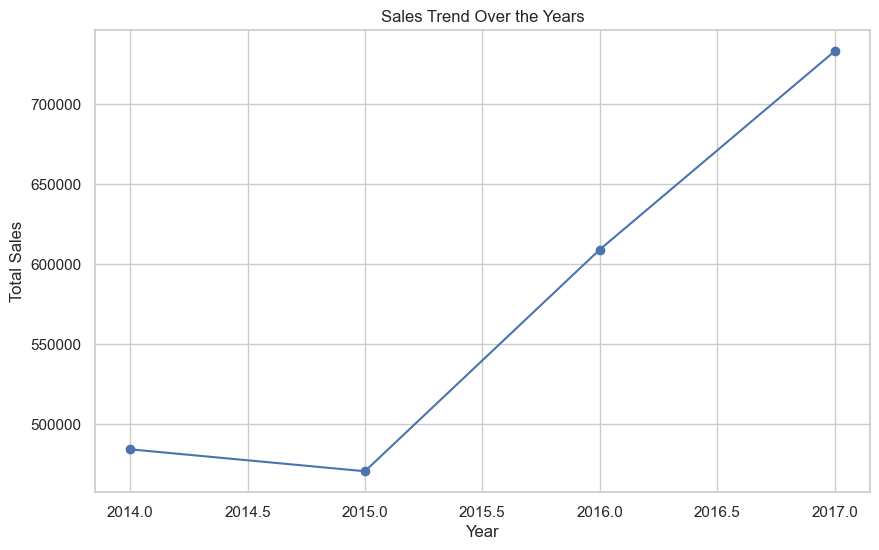

In [9]:
# Extract year
df["Year"] = df["Order Date"].dt.year

sales_by_year = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o')

plt.title("Sales Trend Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

### Sales Distribution by Country

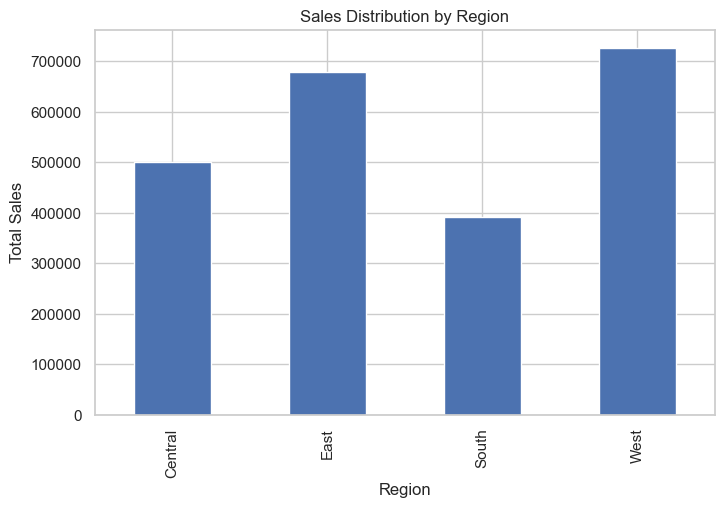

In [13]:
sales_by_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_by_region.plot(kind="bar")

plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Data Visualization with Seaborn

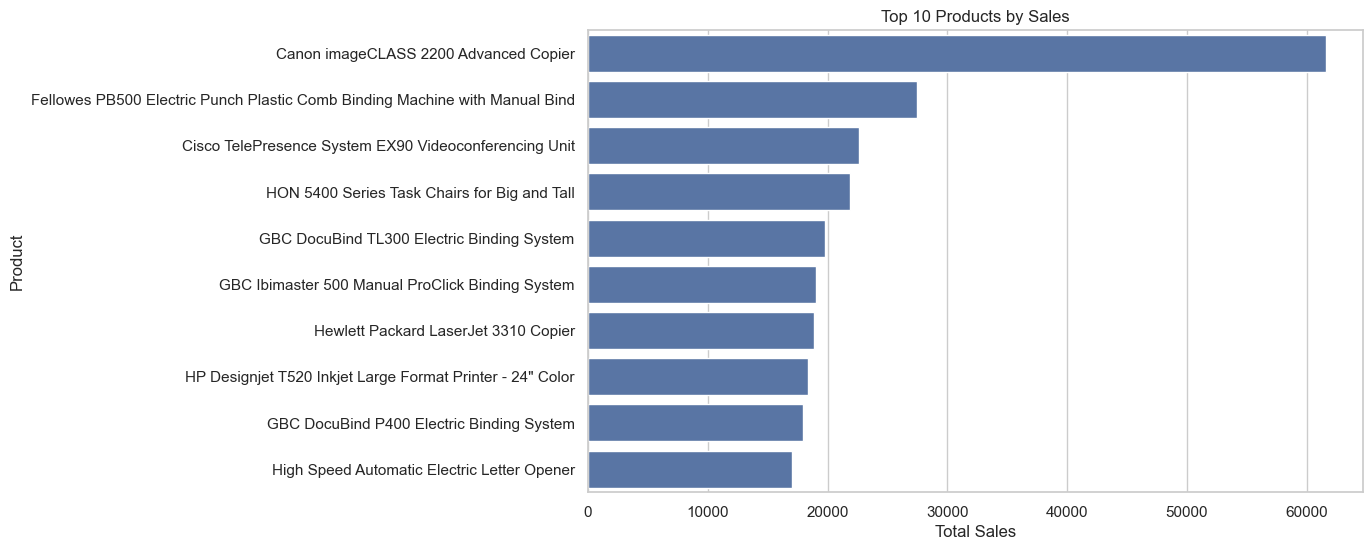

In [16]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

### Scatter Plot: Profit vs Discount

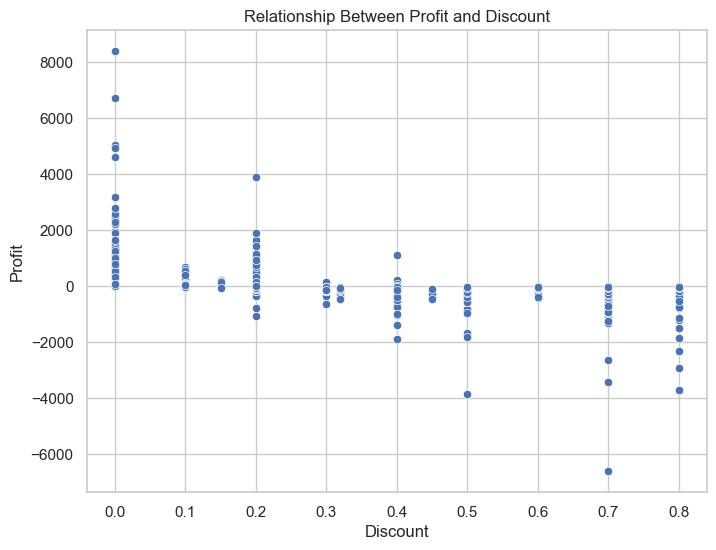

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Relationship Between Profit and Discount")

plt.show()

This plot helps determine whether higher discounts reduce profitability.

Often we observe:

- high discounts → lower profits
- sometimes even negative profits.

### Comparative Analysis: Matplotlib vs Seaborn

### Matplotlib

#### Advantages:

- Highly customizable
- Flexible for complex visualizations
- Suitable for interactive and detailed control

#### Disadvantages:

- Requires more code
- Less visually appealing by default

### Seaborn

#### Advantages:

- Built on top of Matplotlib
- Produces beautiful statistical plots easily
- Requires less code

#### Disadvantages:

- Slightly less flexible for highly customized plots